In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url)

print(df.head())

   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation


In [2]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(31962, 3)

Missing Values:
id       0
label    0
tweet    0
dtype: int64


In [3]:
df = df[['label','tweet']]

print(df.head())

   label                                              tweet
0      0   @user when a father is dysfunctional and is s...
1      0  @user @user thanks for #lyft credit i can't us...
2      0                                bihday your majesty
3      0  #model   i love u take with u all the time in ...
4      0             factsguide: society now    #motivation


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

X = df['tweet']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 95.12 %


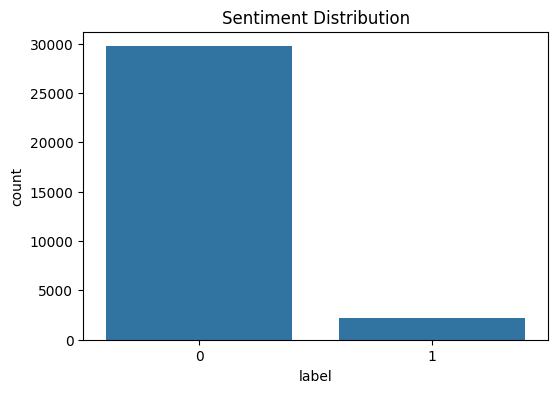

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")

plt.show()

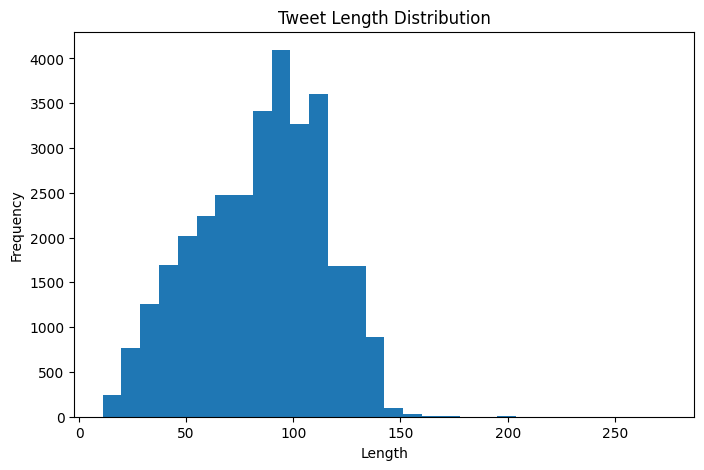

In [6]:
tweet_lengths = df['tweet'].apply(len)

plt.figure(figsize=(8,5))

plt.hist(tweet_lengths, bins=30)

plt.title("Tweet Length Distribution")

plt.xlabel("Length")

plt.ylabel("Frequency")

plt.show()

In [7]:
sample = ["This product is amazing and useful"]

sample_vec = vectorizer.transform(sample)

prediction = model.predict(sample_vec)

print("Prediction:", prediction)

Prediction: [0]
